In [33]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
import matplotlib.colors as colors

In [2]:
gdf = gpd.read_file("../data_processed/reaches_final.gpkg")

In [3]:
gdf.head()

,Permanent_,FDate,Resolution,GNIS_ID,GNIS_Name,LengthKM,ReachCode,FlowDir,WBArea_Per,FType,...,reach_road_stats_sum,reach_road_stats_mean,reach_road_stats_median,reach_road_stats_stddev,reach_road_stats_minority,reach_road_stats_majority,reach_road_stats_q1,reach_road_stats_q3,reach_road_stats_iqr,geometry
0,60585024,2015-11-27,2,NaN,NaN,1.508,16020102000634,1,NaN,460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((448508.352 4514326.181, 448508..."
1,60585024,2015-11-27,2,NaN,NaN,1.508,16020102000634,1,NaN,460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((448629.873 4514436.295, 448629..."
2,60585024,2015-11-27,2,NaN,NaN,1.508,16020102000634,1,NaN,460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((448867.263 4514530.178, 448893..."
3,60585024,2015-11-27,2,NaN,NaN,1.508,16020102000634,1,NaN,460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((449075.31 4514571.472, 449085...."
4,60585024,2015-11-27,2,NaN,NaN,1.508,16020102000634,1,NaN,460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((449278.488 4514599.079, 449285..."


In [4]:
gdf.columns

Index(['Permanent_', 'FDate', 'Resolution', 'GNIS_ID', 'GNIS_Name', 'LengthKM',
       'ReachCode', 'FlowDir', 'WBArea_Per', 'FType', 'FType_Text', 'FCode',
       'FCode_Text', 'Enabled', 'InUtah', 'IsMajor', 'Submerged', 'reach_id',
       'slope_fid', 'slope_count', 'slope_unique', 'slope_min', 'slope_max',
       'slope_range', 'slope_sum', 'slope_mean', 'slope_median',
       'slope_stddev', 'slope_minority', 'slope_majority', 'slope_q1',
       'slope_q3', 'slope_iqr', 'elev_fid', 'elev_count', 'elev_unique',
       'elev_min', 'elev_max', 'elev_range', 'elev_sum', 'elev_mean',
       'elev_median', 'elev_stddev', 'elev_minority', 'elev_majority',
       'elev_q1', 'elev_q3', 'elev_iqr', 'reach_area_stats_fid',
       'reach_area_stats_count', 'reach_area_stats_unique',
       'reach_area_stats_min', 'reach_area_stats_max',
       'reach_area_stats_range', 'reach_area_stats_sum',
       'reach_area_stats_mean', 'reach_area_stats_median',
       'reach_area_stats_stddev', 'reach_a

In [5]:
# create a buffer_area_km2 feature
gdf["buffer_area_km2"] = gdf["buffer_area_m2"] / 1e6

In [6]:
gdf.columns

Index(['Permanent_', 'FDate', 'Resolution', 'GNIS_ID', 'GNIS_Name', 'LengthKM',
       'ReachCode', 'FlowDir', 'WBArea_Per', 'FType', 'FType_Text', 'FCode',
       'FCode_Text', 'Enabled', 'InUtah', 'IsMajor', 'Submerged', 'reach_id',
       'slope_fid', 'slope_count', 'slope_unique', 'slope_min', 'slope_max',
       'slope_range', 'slope_sum', 'slope_mean', 'slope_median',
       'slope_stddev', 'slope_minority', 'slope_majority', 'slope_q1',
       'slope_q3', 'slope_iqr', 'elev_fid', 'elev_count', 'elev_unique',
       'elev_min', 'elev_max', 'elev_range', 'elev_sum', 'elev_mean',
       'elev_median', 'elev_stddev', 'elev_minority', 'elev_majority',
       'elev_q1', 'elev_q3', 'elev_iqr', 'reach_area_stats_fid',
       'reach_area_stats_count', 'reach_area_stats_unique',
       'reach_area_stats_min', 'reach_area_stats_max',
       'reach_area_stats_range', 'reach_area_stats_sum',
       'reach_area_stats_mean', 'reach_area_stats_median',
       'reach_area_stats_stddev', 'reach_a

In [7]:
gdf[[
    "reach_id",
    "elev_mean",
    "slope_mean",
    "reach_area_stats_mean",
    "road_density_km2"
]].describe()

,reach_id,elev_mean,slope_mean,reach_area_stats_mean,road_density_km2
count,57752.00000,57747.000000,57735.000000,57747.000000,57752.000000
mean,28876.50000,1899.579891,9.120859,1.051271,2.042339
std,16671.71071,377.540565,7.526539,4.425522,2.849727
min,1.00000,1280.801432,0.000000,0.000000,0.000000
25%,14438.75000,1624.945795,2.631495,0.001279,0.000000
50%,28876.50000,1945.425916,7.675079,0.055001,0.000000
75%,43314.25000,2151.602670,13.609297,0.425563,3.236067
max,57752.00000,3172.630835,59.255625,173.723675,31.066701


In [8]:
# convert null road values to zero
gdf["road_density_km2"] = gdf["road_density_km2"].fillna(0)

array([[<Axes: title={'center': 'reach_area_stats_mean_log'}>,
        <Axes: title={'center': 'road_density_km2_log'}>],
       [<Axes: title={'center': 'slope_mean'}>,
        <Axes: title={'center': 'elev_mean'}>]], dtype=object)

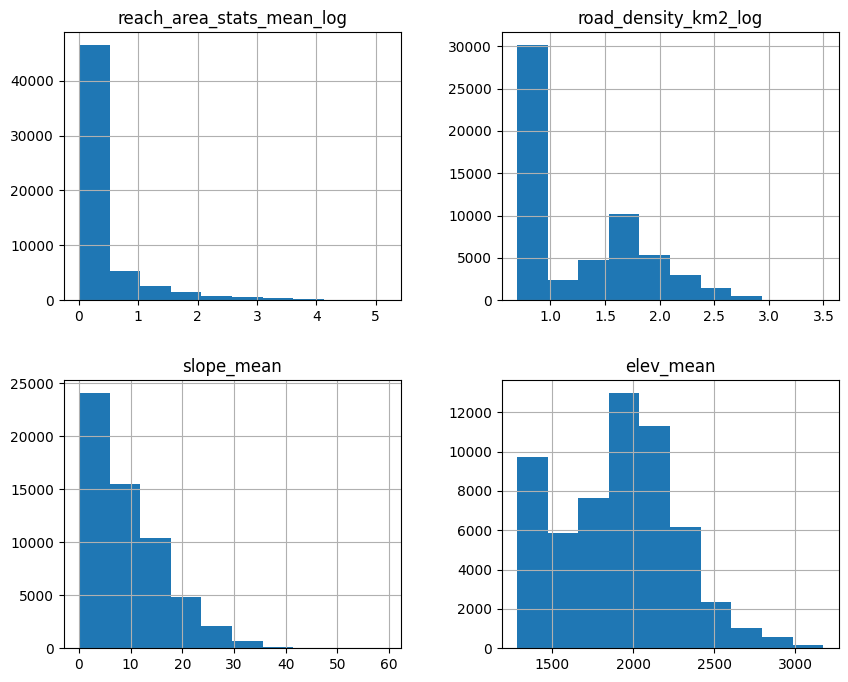

In [9]:
# Log transform variables with skewed distributions
gdf["road_density_km2_log"] = np.log1p(gdf["road_density_km2"]+1)
gdf["reach_area_stats_mean_log"] = np.log1p(gdf["reach_area_stats_mean"])
# check distributions
gdf[["reach_area_stats_mean_log", "road_density_km2_log", "slope_mean", "elev_mean"]].hist(figsize=(10,8))

NOTES

Log-drainage area is skewed even after the transformation because the area of study has many small tributaries and few large mainstream reaches. This pattern is expected in river networks according to the power_law structure. The variable is usable.

Log-road density has a spike near zero due to the high occurence of reaches that have no nearby roads in the buffer zone. The distribution outside the spike is smooth. This pattern is common in ecological disturbance variables. Thus the variable is usable

The mean slope distribution shows that most reaches lie between 0 and 15 degrees. This is normal for mountainous basins like the upper and lower weber basins. A log transformation will not be necessary in order for this variable to be useful.

Mean elevation shows a bell-like distribution cebtered around 2000m, making it almost ideal for regression. No transformation needed.

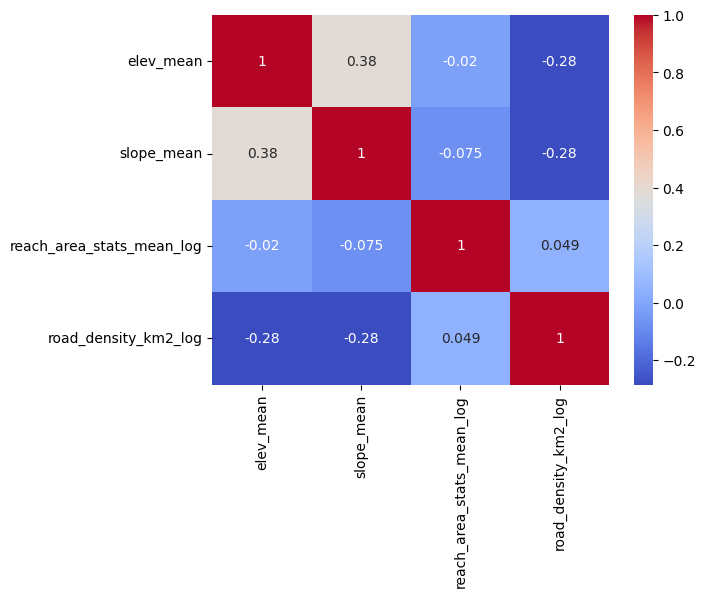

In [10]:
# correlation between predictors

corr = gdf[[
    "elev_mean",
    "slope_mean",
    "reach_area_stats_mean_log",
    "road_density_km2_log"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Elevation and slope are slightly more correlated than the other predictors as expected, but below the typical threshold for colinearity (usually |r| > 0.7)

Text(0.5, 1.0, 'Road Density vs Elevation')

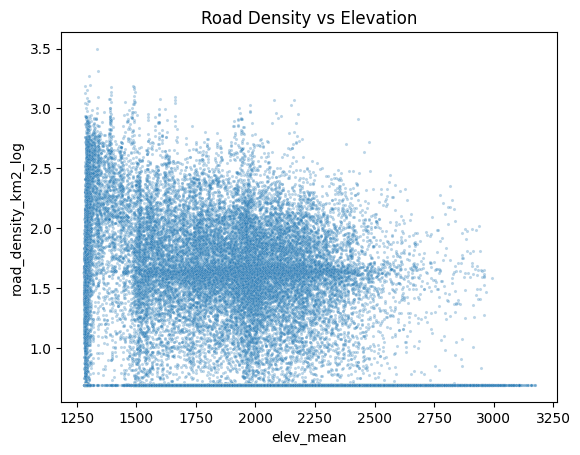

In [11]:
# exploratory relationshsips

sns.scatterplot(
    x="elev_mean",
    y="road_density_km2_log",
    data=gdf,
    alpha=0.3,
    s = 5
)
plt.title("Road Density vs Elevation")


High elevation --> low disturbance

This reinforces the correlation matrix

Text(0.5, 1.0, 'Road Density vs Reach Area')

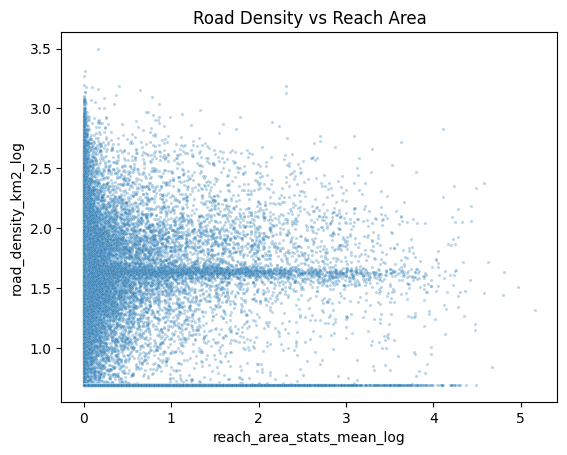

In [12]:
sns.scatterplot(
    x="reach_area_stats_mean_log",
    y="road_density_km2_log",
    data=gdf,
    alpha=0.3,
    s = 5
)
plt.title("Road Density vs Reach Area")

Large drainage area --> rarely have high road density

c:\GIS\GIS\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


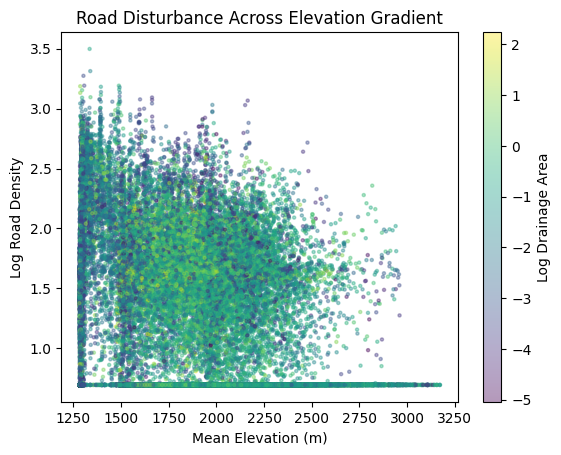

In [30]:
plt.scatter(
    gdf["elev_mean"],
    gdf["road_density_km2_log"],
    c=np.log10(gdf["reach_area_stats_mean"]),
    cmap="viridis",
    s=5,
    alpha=0.4
)

plt.xlabel("Mean Elevation (m)")
plt.ylabel("Log Road Density")
plt.title("Road Disturbance Across Elevation Gradient")

cbar = plt.colorbar()
cbar.set_label("Log Drainage Area")

plt.savefig("outputs/elevation_disturbance_gradient.png", dpi=300, bbox_inches="tight")
plt.show()

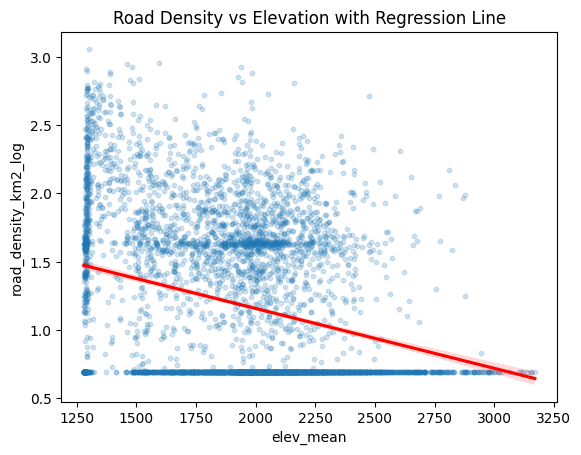

In [28]:
sns.regplot(
    x="elev_mean",
    y="road_density_km2_log",
    data=gdf.sample(5000),
    scatter_kws={"alpha":0.2, "s":10},
    line_kws={"color":"red"}
)
plt.title("Road Density vs Elevation with Regression Line")
plt.savefig("outputs/road_density_elevation_regression.png", dpi=300, bbox_inches="tight")
plt.show()

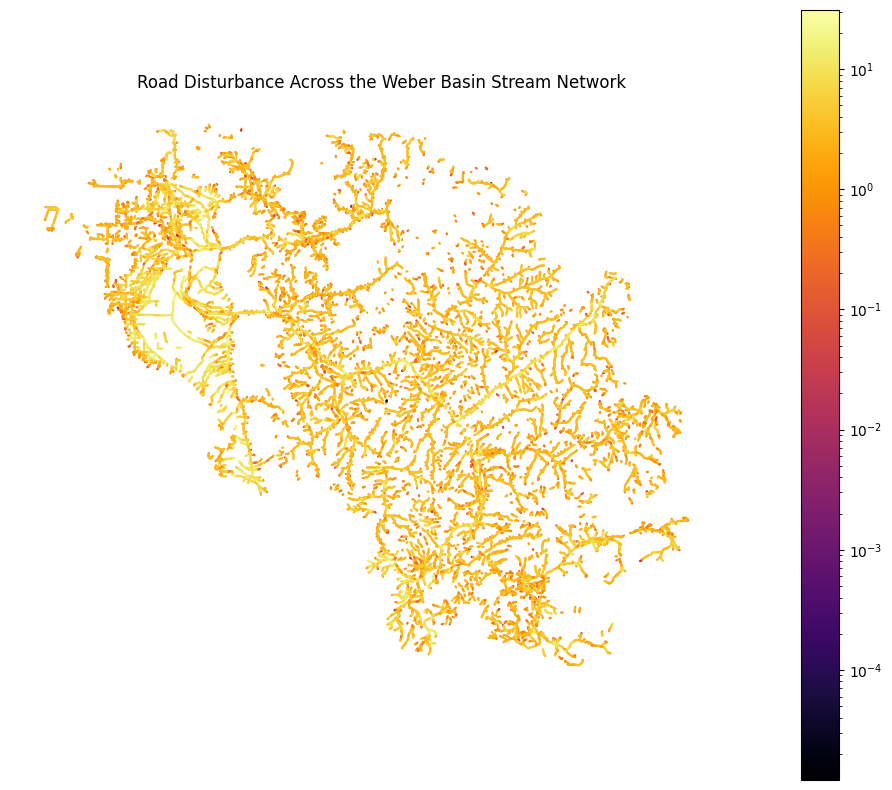

In [ ]:
fig, ax = plt.subplots(figsize=(12,10))

basin_boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
)

gdf.plot(
    ax=ax,
    column="road_density_km2",
    cmap="inferno",
    linewidth=0.25,
    legend=True,
    norm=colors.LogNorm()
)

ax.set_title("Road Disturbance Across the Weber Basin Stream Network")
ax.axis("off")